# Ciência de Dados e Jogos Digitais: Explorando o Steam Games Dataset

Este notebook foi preparado para uma **análise exploratória (EDA)** do Steam Games Dataset, mantido por Fronkon Games e disponibilizado no Hugging Face.

> **Unidade de análise:** cada linha representa um jogo, e não um usuário.

O objetivo é percorrer os campos do dataset e usar código para responder perguntas simples sobre os dados, preparando o caminho para análises e visualizações mais avançadas.

Fonte do arquivo:
`https://huggingface.co/datasets/FronkonGames/steam-games-dataset/resolve/main/data/train-00000-of-00001.parquet`

Arquivo de output:
`games_steam.csv`

## 1. Bibliotecas

Vamos utilizar principalmente:

- **pandas** para manipulação dos dados;
- **numpy** para operações numéricas;
- **matplotlib** e **seaborn** para visualizações;
- **ast** para interpretar campos que podem estar armazenados como listas em formato de texto.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
sns.set_theme()

## 2. Carregando o dataset

O arquivo está no formato **Parquet**. O pandas consegue carregá-lo diretamente pela URL.

In [ ]:
# Dataset local
# URL = "train-00000-of-00001.parquet"
URL = "https://huggingface.co/datasets/FronkonGames/steam-games-dataset/resolve/main/data/train-00000-of-00001.parquet"

dados = pd.read_parquet(URL)

print(f"Linhas: {dados.shape[0]:,}")
print(f"Colunas: {dados.shape[1]}")

Linhas: 124,146
Colunas: 41


## 3. Visão geral do dataset

Antes de analisar cada variável, vamos descobrir quais campos existem, seus tipos e alguns exemplos.

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124146 entries, 0 to 124145
Data columns (total 41 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   appID                     124146 non-null  object 
 1   name                      124146 non-null  object 
 2   release_date              124146 non-null  object 
 3   estimated_owners          124146 non-null  object 
 4   peak_ccu                  124146 non-null  int64  
 5   required_age              124146 non-null  int64  
 6   price                     124146 non-null  float64
 7   dlc_count                 124146 non-null  int64  
 8   detailed_description      124146 non-null  object 
 9   short_description         124146 non-null  object 
 10  supported_languages       124146 non-null  object 
 11  full_audio_languages      124146 non-null  object 
 12  reviews                   124146 non-null  object 
 13  header_image              124146 non-null  o

In [ ]:
dados.head()

,appID,name,release_date,estimated_owners,peak_ccu,required_age,price,dlc_count,detailed_description,short_description,supported_languages,full_audio_languages,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,user_score,positive,negative,score_rank,achievements,recommendations,notes,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,developers,publishers,categories,genres,tags,screenshots,movies,packages
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,,,[],[],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/header.jpg?t=1699268702,,,,True,False,False,0,,0,0,0,,0,0,,0,0,0,0,[],[],[],[],[],[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/ss_7d9504b958d0b143d053d31cb74b375daba33...,[],[]
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,0,"Springtime, April: when the cherry trees come into full bloom. The protagonist Yukinari Sanada has returned to his h...","Spring has come, and our protagonist, Yukinari, returns home after 7 years. Between his second cousin Sakura, who me...",[English],[],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/496350/header.jpg?t=1725519097,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,,0,252,3,,0,231,,8,0,8,0,[minori],[MangaGamer],"[Single-player, Steam Trading Cards, Steam Cloud, Family Sharing]",[Adventure],[],[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/496350/ss_0a5ff85870a1c2221e495b75a5c7b9e248eb32...,[],"[{""title"": ""Buy Supipara - Chapter 1 Spring Has Come!"", ""description"": """", ""subs"": [{""text"": ""Supipara - Alice the m..."
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,"Immerse yourself in the most beloved, mystical and entrancing world of Edgar Allan Poe's ''The Raven!'' This work re...",Discover an entrancing and spectacular world!,"[English, French, German, Russian]",[],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/1034400/header.jpg?t=1687434115,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,,0,21,3,,0,0,,0,0,0,0,[Somer Games],[8floor],"[Single-player, Family Sharing]",[Casual],[],[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/1034400/ss_12d8bb27a16046fe548818dcd0f5d7d0e2038...,[],"[{""title"": ""Buy Mystery Solitaire The Black Raven"", ""description"": """", ""subs"": [{""text"": ""Mystery Solitaire The Blac..."
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' It's been three years since I've repeated such greetings. Hiyoro, who ...",Yuha! I'll start the broadcast! Hakko's extreme survival time,[Korean],[Korean],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3292190/header.jpg?t=1742217574,,,yujingamesc@gmail.com,True,False,False,0,,0,0,0,,19,0,The game includes the following elements. 1. General Mature Content : Revealing outfits; sexual stimulation; sexual ...,0,0,0,0,[유진게임즈],[유진게임즈],"[Single-player, Steam Achievements, Family Sharing]","[Casual, Indie, Simulation]",[],[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3292190/ss_87f071dbf846e7832ff49d68b0d7a8b6509bc...,[],"[{""title"": ""Buy \ubc84\ud29c\ubc84 \ud30c\ub77c\ub178\uc774\uc544 - Vtuber Paranoia"", ""description"": """", ""subs"": [{""..."
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,"Its not just a Maze; its a Quest! Enter the captivating realm of Maze Quest, where each unexpected turn presents fre...","Its not just a Maze; its a Quest! Enter the captivating realm of Maze Quest, where each unexpected turn presents fre...",[English],[English],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3631080/2a78ae30e350862e415889f097e422855eca25b9/.

In [ ]:
dados.columns.tolist()

['appID',
 'name',
 'release_date',
 'estimated_owners',
 'peak_ccu',
 'required_age',
 'price',
 'dlc_count',
 'detailed_description',
 'short_description',
 'supported_languages',
 'full_audio_languages',
 'reviews',
 'header_image',
 'website',
 'support_url',
 'support_email',
 'windows',
 'mac',
 'linux',
 'metacritic_score',
 'metacritic_url',
 'user_score',
 'positive',
 'negative',
 'score_rank',
 'achievements',
 'recommendations',
 'notes',
 'average_playtime_forever',
 'average_playtime_2weeks',
 'median_playtime_forever',
 'median_playtime_2weeks',
 'developers',
 'publishers',
 'categories',
 'genres',
 'tags',
 'screenshots',
 'movies',
 'packages']

## 4. Estatísticas

Para as variáveis numéricas, podemos observar quantidade de valores, média, desvio-padrão, mínimo e quartis.

In [ ]:
colunas_describe = [
    "appID",
    "price",
    "peak_ccu",
    "positive",
    "negative",
    "achievements",
    "recommendations"
]

dados[colunas_describe].describe().T

,count,mean,std,min,25%,50%,75%,max
price,124146.0,4.786144,12.507614,0.0,0.55,2.39,5.39,999.98
peak_ccu,124146.0,53.918338,3706.328223,0.0,0.00,0.00,0.00,1013936.00
positive,124146.0,1032.102677,27917.759100,0.0,0.00,5.00,36.00,7642084.00
negative,124146.0,167.115453,5341.347505,0.0,0.00,1.00,10.00,1173003.00
achievements,124146.0,18.010520,140.633042,0.0,0.00,2.00,19.00,9821.00
recommendations,124146.0,950.117112,21743.392322,0.0,0.00,0.00,0.00,4830455.00


## 5. Valores ausentes

A primeira pergunta sobre qualquer dataset deve ser: **onde estão os dados faltantes?**

In [ ]:
nulos = dados.isna().sum().sort_values(ascending=False)

nulos_df = pd.DataFrame({
    "nulos": nulos,
    "percentual": (nulos / len(dados) * 100).round(2)
})

nulos_df.head(20)

,nulos,percentual
appID,0,0.0
name,0,0.0
release_date,0,0.0
estimated_owners,0,0.0
peak_ccu,0,0.0
required_age,0,0.0
price,0,0.0
dlc_count,0,0.0
detailed_description,0,0.0
short_description,0,0.0


# 6. Identificação e informações básicas

`appID`

É o identificador do aplicativo/jogo na Steam.

Perguntas:

- Existem IDs duplicados?
- Qual é o intervalo dos IDs?
- O `appID` pode ser usado como identificador único?

In [ ]:
print("IDs únicos:", dados["appID"].nunique())
print("Linhas:", len(dados))
print("IDs duplicados:", dados["appID"].duplicated().sum())

dados["appID"].describe()

IDs únicos: 124146
Linhas: 124146
IDs duplicados: 0


count      124146
unique     124146
top       2539430
freq            1
Name: appID, dtype: object

In [ ]:
dados[dados["appID"].duplicated(keep=False)].sort_values("appID").head(20)

,appID,name,release_date,estimated_owners,peak_ccu,required_age,price,dlc_count,detailed_description,short_description,supported_languages,full_audio_languages,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,user_score,positive,negative,score_rank,achievements,recommendations,notes,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,developers,publishers,categories,genres,tags,screenshots,movies,packages


`name`
Nome do jogo.

Vamos observar exemplos, nomes ausentes e possíveis duplicidades.

In [ ]:
total = len(dados)
nomes_unicos = dados["name"].nunique()
diferenca = total - nomes_unicos

print("Total de registros:", total)
print("Nomes únicos:", nomes_unicos)
print("Diferença:", diferenca)
print("Nomes ausentes:", dados["name"].isna().sum())

percentual = (diferenca / total) * 100
print(f"Percentual de registros além dos nomes únicos: {percentual:.2f}%")

# quantos nomes aparecem mais de uma vez
nomes_repetidos = dados["name"].value_counts()
nomes_repetidos = nomes_repetidos[nomes_repetidos > 1]

print("Nomes que aparecem mais de uma vez:", len(nomes_repetidos))

dados[["appID", "name"]].head(20)

Total de registros: 124146
Nomes únicos: 122974
Diferença: 1172
Nomes ausentes: 0
Percentual de registros além dos nomes únicos: 0.94%
Nomes que aparecem mais de uma vez: 974


,appID,name
0,2539430,Black Dragon Mage Playtest
1,496350,Supipara - Chapter 1 Spring Has Come!
2,1034400,Mystery Solitaire The Black Raven
3,3292190,버튜버 파라노이아 - Vtuber Paranoia
4,3631080,Maze Quest VR
5,1654170,Agony VR
6,1934300,Armored Brigade II
7,700340,Galacatraz: Eject Equip Escape
8,1157670,Hepta Beats
9,1540330,MUMBA IV: Egypt Jewels


In [ ]:
duplicados_nome = (
    dados[dados["name"].duplicated(keep=False)]
    .sort_values("name")
)

duplicados_nome[[
    "appID",
    "name",
    "release_date",
    "price",
    "estimated_owners",
    "genres",
    "notes"
]].head(50)

,appID,name,release_date,price,estimated_owners,genres,notes
30085,3022780,A Better Tomorrow,"Jul 31, 2024",0.00,0 - 20000,"[Casual, Strategy, Free To Play]",
108086,3763930,A Better Tomorrow,"Sep 30, 2025",0.00,0 - 0,"[Indie, Free To Play, Early Access]","The game features contains LGBT content, vulgar language, bloody scenes, adult nudity, violence, and non-consensual ..."
53193,557900,A Walk in the Woods,"Apr 21, 2020",0.00,0 - 20000,"[Indie, Simulation]",
62608,842420,A Walk in the Woods,"May 1, 2018",0.00,100000 - 200000,"[Adventure, Free To Play, Indie]",
17238,1544540,ALONE,"May 31, 2021",0.74,50000 - 100000,"[Adventure, Casual, Indie]",Violent References Strong Language
100222,1826070,ALONE,"Dec 23, 2021",8.99,0 - 20000,"[Action, Adventure, Indie]",
23341,1768480,ASTRA,"Oct 12, 2021",0.89,0 - 20000,"[Action, Adventure, Casual, Indie]",May cause epilepsy
121843,1522190,ASTRA,"Feb 26, 2021",0.00,0 - 20000,[Audio Production],
87683,2691830,ASTRA,"Jan 5, 2024",2.99,20000 - 50000,[Action],"Lo-fi depictions of gore, implied alcohol use."
124064,3571480,ASTRAL,"Jan 30, 2026",14.99,0 - 0,"[Action, Indie, Early Access]",


`release_date`
Data de lançamento.

Primeiro convertemos a coluna para formato de data. Depois podemos estudar a quantidade de jogos lançados por ano.

In [ ]:
dados["release_date_dt"] = pd.to_datetime(
    dados["release_date"],
    errors="coerce"
)

print("Datas válidas:", dados["release_date_dt"].notna().sum())
print("Datas inválidas/ausentes:", dados["release_date_dt"].isna().sum())

dados[["name", "release_date", "release_date_dt"]].head(10)

Datas válidas: 124146
Datas inválidas/ausentes: 0


,name,release_date,release_date_dt
0,Black Dragon Mage Playtest,"Aug 1, 2023",2023-08-01
1,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",2016-07-29
2,Mystery Solitaire The Black Raven,"May 6, 2019",2019-05-06
3,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",2024-10-31
4,Maze Quest VR,"Apr 24, 2025",2025-04-24
5,Agony VR,"Apr 5, 2023",2023-04-05
6,Armored Brigade II,"Apr 8, 2025",2025-04-08
7,Galacatraz: Eject Equip Escape,"Feb 1, 2018",2018-02-01
8,Hepta Beats,"May 7, 2021",2021-05-07
9,MUMBA IV: Egypt Jewels,"Dec 13, 2021",2021-12-13


In [ ]:
# Quantidade de jogos lançados por ano
dados["release_year"] = dados["release_date_dt"].dt.year

lancamentos_ano = (
    dados["release_year"]
    .value_counts()
    .sort_index()
)

lancamentos_ano.tail(20)

release_year
2007       90
2008      158
2009      321
2010      255
2011      260
2012      322
2013      467
2014     1523
2015     2515
2016     4141
2017     5921
2018     7461
2019     7242
2020     8804
2021    11067
2022    12285
2023    14596
2024    20031
2025    24973
2026     1617
Name: count, dtype: int64

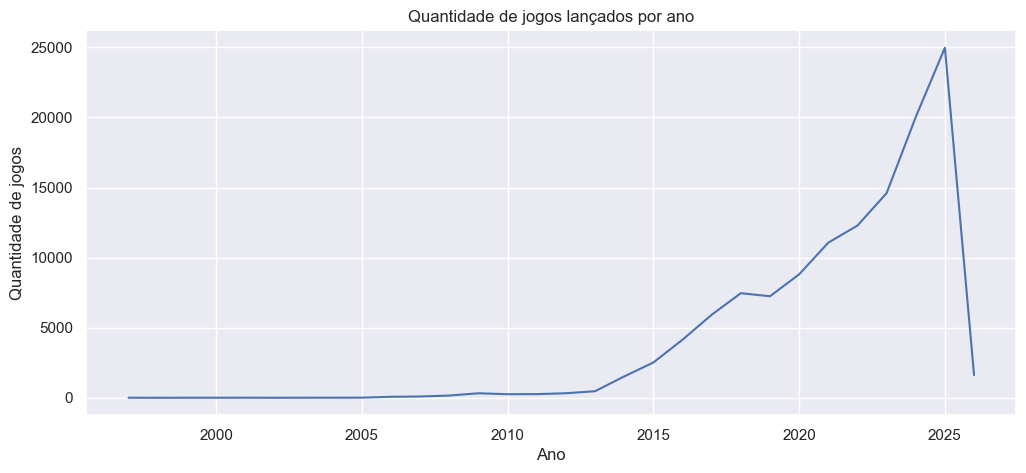

In [ ]:
lancamentos_ano.plot(kind="line", figsize=(12,5))
plt.title("Quantidade de jogos lançados por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de jogos")
plt.show()

# 7. Mercado e popularidade

`estimated_owners`
Este campo representa uma **estimativa de proprietários**, normalmente apresentada como uma faixa.

Não devemos tratá-lo como vendas exatas.

Vamos primeiro descobrir os valores existentes.

In [ ]:
dados["estimated_owners"].value_counts(dropna=False).head(20)

estimated_owners
0 - 20000                75545
0 - 0                    23033
20000 - 50000            11397
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2854
500000 - 1000000          1154
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

### Criando o ponto médio de `estimated_owners`

Para facilitar algumas análises, vamos transformar faixas como `20000 - 50000` em um ponto médio.

Esse valor será apenas um **indicador auxiliar/proxy**, não uma quantidade exata de vendas.

In [ ]:
def ponto_medio(valor):
    if pd.isna(valor):
        return np.nan

    texto = str(valor).replace(",", "").strip()
    numeros = re.findall(r"\d+", texto)

    if len(numeros) >= 2:
        minimo = int(numeros[0])
        maximo = int(numeros[1])
        return (minimo + maximo) / 2

    if len(numeros) == 1:
        return float(numeros[0])

    return np.nan

dados["estimated_owners_mid"] = dados["estimated_owners"].apply(ponto_medio)

dados[["name", "estimated_owners", "estimated_owners_mid"]].head(20)

,name,estimated_owners,estimated_owners_mid
0,Black Dragon Mage Playtest,0 - 0,0.0
1,Supipara - Chapter 1 Spring Has Come!,0 - 20000,10000.0
2,Mystery Solitaire The Black Raven,0 - 20000,10000.0
3,버튜버 파라노이아 - Vtuber Paranoia,0 - 20000,10000.0
4,Maze Quest VR,0 - 20000,10000.0
5,Agony VR,0 - 20000,10000.0
6,Armored Brigade II,0 - 20000,10000.0
7,Galacatraz: Eject Equip Escape,0 - 20000,10000.0
8,Hepta Beats,0 - 20000,10000.0
9,MUMBA IV: Egypt Jewels,0 - 20000,10000.0


In [ ]:
resumo_owners = pd.DataFrame({
    "Métrica": [
        "Quantidade de jogos",
        "Média",
        "Mediana",
        "Mínimo",
        "Percentil 25%",
        "Percentil 75%",
        "Percentil 95%",
        "Percentil 99%",
        "Máximo"
    ],
    "Proprietários estimados": [
        dados["estimated_owners_mid"].count(),
        dados["estimated_owners_mid"].mean(),
        dados["estimated_owners_mid"].median(),
        dados["estimated_owners_mid"].min(),
        dados["estimated_owners_mid"].quantile(.25),
        dados["estimated_owners_mid"].quantile(.75),
        dados["estimated_owners_mid"].quantile(.95),
        dados["estimated_owners_mid"].quantile(.99),
        dados["estimated_owners_mid"].max()
    ]
})

resumo_owners["Proprietários estimados"] = (
    resumo_owners["Proprietários estimados"]
    .map(lambda x: f"{x:,.0f}")
)

resumo_owners

,Métrica,Proprietários estimados
0,Quantidade de jogos,"124,146"
1,Média,"84,674"
2,Mediana,"10,000"
3,Mínimo,0
4,Percentil 25%,"10,000"
5,Percentil 75%,"10,000"
6,Percentil 95%,"150,000"
7,Percentil 99%,"1,500,000"
8,Máximo,"150,000,000"


### Jogos com maior número estimado de proprietários

In [ ]:
dados[[
    "name",
    "estimated_owners",
    "estimated_owners_mid"
]].sort_values(
    "estimated_owners_mid",
    ascending=False
).head(20)

,name,estimated_owners,estimated_owners_mid
4193,Dota 2,100000000 - 200000000,150000000.0
8878,PUBG: BATTLEGROUNDS,100000000 - 200000000,150000000.0
45509,Counter-Strike 2,100000000 - 200000000,150000000.0
54502,Apex Legends™,100000000 - 200000000,150000000.0
27431,Call of Duty®,50000000 - 100000000,75000000.0
59122,Grand Theft Auto V Legacy,50000000 - 100000000,75000000.0
44134,Black Myth: Wukong,50000000 - 100000000,75000000.0
21033,Lost Ark,50000000 - 100000000,75000000.0
16827,Palworld,50000000 - 100000000,75000000.0
57377,Team Fortress 2,50000000 - 100000000,75000000.0


## `peak_ccu`

CCU significa **Concurrent Users**. É o pico de usuários simultâneos observado no período de referência.

Não significa número de vendas nem número de usuários únicos.

In [ ]:
peak = dados["peak_ccu"]

resumo_ccu = pd.DataFrame({
    "Métrica": [
        "Quantidade de jogos",
        "Média",
        "Mediana",
        "Mínimo",
        "Percentil 25%",
        "Percentil 75%",
        "Percentil 95%",
        "Percentil 99%",
        "Máximo"
    ],
    "Peak CCU": [
        peak.count(),
        peak.mean(),
        peak.median(),
        peak.min(),
        peak.quantile(.25),
        peak.quantile(.75),
        peak.quantile(.95),
        peak.quantile(.99),
        peak.max()
    ]
})

resumo_ccu["Peak CCU"] = (
    resumo_ccu["Peak CCU"]
    .map(lambda x: f"{x:,.0f}")
)

resumo_ccu

,Métrica,Peak CCU
0,Quantidade de jogos,"124,146"
1,Média,54
2,Mediana,0
3,Mínimo,0
4,Percentil 25%,0
5,Percentil 75%,0
6,Percentil 95%,9
7,Percentil 99%,220
8,Máximo,"1,013,936"


In [ ]:
# Mostrar quantos jogos têm CCU igual a zero
zero_ccu = (dados["peak_ccu"] == 0).sum()
percentual_zero = zero_ccu / len(dados) * 100

print(f"Jogos com Peak CCU = 0: {zero_ccu:,}")
print(f"Percentual: {percentual_zero:.2f}%")

Jogos com Peak CCU = 0: 104,468
Percentual: 84.15%


In [ ]:
# Top 20 jogos
dados[["name", "peak_ccu"]].sort_values(
    "peak_ccu",
    ascending=False
).head(20)

,name,peak_ccu
45509,Counter-Strike 2,1013936
4193,Dota 2,623941
8878,PUBG: BATTLEGROUNDS,314682
104347,Bongo Cat,164168
17581,ELDEN RING NIGHTREIGN,163599
5377,Rust,143870
54502,Apex Legends™,124262
109015,Marvel Rivals,106611
86168,Wallpaper Engine,91184
15313,DELTARUNE,83936


# 8. Preço e comercialização

## `price`

O preço está em dólares americanos. Segundo a documentação do dataset, `0.0` representa jogo gratuito.

Vamos separar jogos gratuitos e pagos.

In [ ]:
print("Jogos gratuitos:", (dados["price"] == 0).sum())
print("Jogos pagos:", (dados["price"] > 0).sum())

dados["price"].describe()

Jogos gratuitos: 26412
Jogos pagos: 97734


count    124146.000000
mean          4.786144
std          12.507614
min           0.000000
25%           0.550000
50%           2.390000
75%           5.390000
max         999.980000
Name: price, dtype: float64

In [ ]:
gratuitos = dados[dados["price"] == 0][[
    "name",
    "genres",
    "estimated_owners",
    "estimated_owners_mid"    
]].sort_values(
    "estimated_owners_mid",
    ascending=False
).head(50)

print(gratuitos.to_string(index=False))

                             name                                                                                             genres      estimated_owners  estimated_owners_mid
                           Dota 2                                                                   [Action, Strategy, Free To Play] 100000000 - 200000000           150000000.0
              PUBG: BATTLEGROUNDS                                           [Action, Adventure, Massively Multiplayer, Free To Play] 100000000 - 200000000           150000000.0
                    Apex Legends™                                                                  [Action, Adventure, Free To Play] 100000000 - 200000000           150000000.0
                 Counter-Strike 2                                                                             [Action, Free To Play] 100000000 - 200000000           150000000.0
                         Lost Ark                                      [Action, Adventure, Massively Multiplayer, R

## `dlc_count`

Quantidade de DLCs associadas ao jogo.

DLC significa Downloadable Content, ou conteúdo adicional que pode ser disponibilizado para o jogo.

In [ ]:
dados["dlc_count"].describe()

count    124146.000000
mean          0.540573
std          14.426264
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        3703.000000
Name: dlc_count, dtype: float64

In [ ]:
dados[["name", "dlc_count","genres"]].sort_values(
    "dlc_count",
    ascending=False
).head(20)

,name,dlc_count,genres
122448,Fantasy Grounds VTT,3703,"[Indie, RPG, Strategy, Free To Play]"
81495,Fantasy Grounds Classic,2006,"[Indie, RPG, Strategy]"
97884,RPG Maker MV,1066,"[RPG, Design & Illustration, Education, Web Publishing, Game Development]"
81801,Rocksmith® 2014 Edition REMASTERED LEARN & PLAY,967,"[Casual, Simulation]"
14969,RPG Maker MZ,875,"[RPG, Design & Illustration, Education, Web Publishing, Game Development]"
83990,Train Simulator Classic,782,[Simulation]
115040,Train Simulator Classic,782,[Simulation]
91932,Train Simulator Classic,782,[Simulation]
33745,Train Simulator Classic,782,[Simulation]
64184,Train Simulator Classic,782,[Simulation]


## `required_age`

Idade mínima requerida. O valor `0` representa ausência de restrição etária indicada nesse campo.

In [ ]:
# quantidade de jogos por restrição de idade
contagem_idade = (
    dados["required_age"]
    .value_counts()
    .sort_index()
    .reset_index()
)

contagem_idade.columns = ["idade_minima", "quantidade_jogos"]

contagem_idade

,idade_minima,quantidade_jogos
0,0,122869
1,1,2
2,3,6
3,6,4
4,7,5
5,10,27
6,12,23
7,13,176
8,14,1
9,15,3


In [ ]:
# Concatenador de nomes dos jogos por idade
idade_resumo = (
    dados.groupby("required_age")
    .agg(
        quantidade_jogos=("name", "count"),
        exemplos_jogos=("name", lambda x: ", ".join(x.head(5)))
    )
    .reset_index()
)

idade_resumo

,required_age,quantidade_jogos,exemplos_jogos
0,0,122869,"Black Dragon Mage Playtest, Supipara - Chapter 1 Spring Has Come!, Mystery Solitaire The Black Raven, 버튜버 파라노이아 - Vt..."
1,1,2,"Captain Gazman Day Of The Rage, Beholder"
2,3,6,"Gem Monster, 荒凉城市, VR Coaster Extreme, Turtle's Quest, Celestial"
3,6,4,"DEPLOYMENT, Sumeru, Test Drive: Ferrari Racing Legends, Warbot"
4,7,5,"刀锋突袭, 勇者有点太嚣张。™G(No Hero Allowed: No Puzzle Either!), Dawn of Warriors, Christmas Land: Opposite Worlds, ZOMBIE MATH..."
5,10,27,"Break through 50, Ankh Guardian - Treasure of the Demon's Temple/ゴッド・オブ・ウォール 魔宮の秘宝, Hitman GO: Definitive Edition, D..."
6,12,23,"Dungeon Nightmares II : The Memory, Day of the dead, Adventures of Sadukar - Chapter I, JurassicDragon and the Binar..."
7,13,176,"Injustice: Gods Among Us Ultimate Edition, Shadow Ops: Red Mercury, GUILTY GEAR -STRIVE-, Go! Go! Nippon! ~My First ..."
8,14,1,El Culto
9,15,3,"Eugene's Dream: The Daily Ins And Outs Of A Sane Robot In An Insane World, Killer Elite – Time to Die, Connected Hea..."


In [ ]:
# 20 jogos com maior idade, preco, proprietários, genero, avaliação
idade_jogos = dados[[
    "name",
    "required_age",
    "price",
    "estimated_owners",
    "estimated_owners_mid",
    "genres",
    "positive",
    "negative"
]].sort_values(
    ["required_age", "estimated_owners_mid"],
    ascending=[False, False]
)

idade_jogos.head(20)

,name,required_age,price,estimated_owners,estimated_owners_mid,genres,positive,negative
72537,Paladin's Horn: The Destiny of the Holy Lance,21,9.99,0 - 20000,10000.0,"[Indie, RPG]",0,0
114711,Yet Another Waveshooter,21,4.99,0 - 20000,10000.0,"[Action, Casual]",1,0
71295,Paintings Thief,20,2.99,0 - 20000,10000.0,[Action],0,0
3692,PAYDAY 2,18,0.99,20000000 - 50000000,35000000.0,"[Action, RPG]",594327,68755
8274,Halo: The Master Chief Collection,18,9.99,5000000 - 10000000,7500000.0,[Action],223635,18432
64800,Dying Light 2 Stay Human: Reloaded Edition,18,17.99,5000000 - 10000000,7500000.0,"[Action, Adventure, RPG]",154122,40708
111804,POSTAL 2,18,0.99,5000000 - 10000000,7500000.0,"[Action, Adventure, Indie]",112414,3644
31831,METAL GEAR SOLID V: THE PHANTOM PAIN,18,19.99,2000000 - 5000000,3500000.0,"[Action, Adventure]",91675,8247
36032,Vampire: The Masquerade - Bloodhunt,18,0.00,2000000 - 5000000,3500000.0,"[Action, Free To Play]",43433,13651
41350,Kingdom Come: Deliverance II,18,29.99,2000000 - 5000000,3500000.0,"[Action, Adventure, RPG]",96279,6058


# 9. Descrições e texto

## `detailed_description`, `short_description` e `notes`

São campos textuais. Nesta primeira exploração, vamos medir:

- quantidade de valores ausentes;
- tamanho médio do texto por caracteres;
- jogos com descrições mais longas.

In [ ]:
colunas_texto = [
    "detailed_description",
    "short_description",
    "notes"
]

for coluna in colunas_texto:
    tamanho = dados[coluna].fillna("").astype(str).str.len()
    print(f"\n{coluna}")
    print("Ausentes:", dados[coluna].isna().sum())
    print("Tamanho médio:", round(tamanho.mean(), 2))
    print("Maior tamanho:", tamanho.max())


detailed_description
Ausentes: 0
Tamanho médio: 1232.46
Maior tamanho: 89666

short_description
Ausentes: 0
Tamanho médio: 184.79
Maior tamanho: 342

notes
Ausentes: 0
Tamanho médio: 30.48
Maior tamanho: 2024


In [ ]:
dados[["name", "short_description"]].dropna().head(10)

,name,short_description
0,Black Dragon Mage Playtest,
1,Supipara - Chapter 1 Spring Has Come!,"Spring has come, and our protagonist, Yukinari, returns home after 7 years. Between his second cousin Sakura, who me..."
2,Mystery Solitaire The Black Raven,Discover an entrancing and spectacular world!
3,버튜버 파라노이아 - Vtuber Paranoia,Yuha! I'll start the broadcast! Hakko's extreme survival time
4,Maze Quest VR,"Its not just a Maze; its a Quest! Enter the captivating realm of Maze Quest, where each unexpected turn presents fre..."
5,Agony VR,Agony VR is a first-person survival horror game. You will take on a role of trapped soul placed in the middle of hel...
6,Armored Brigade II,"Armored Brigade II revolutionizes real-time tactical warfare in 3D, focusing on the intense combined arms combat of ..."
7,Galacatraz: Eject Equip Escape,"Escape Galacatraz, the universe's most secure detainment facility, in this side scrolling twin stick shooter! GAMEPA..."
8,Hepta Beats,"Hepta Beats is a 2D side-view platformer game in which the levels are controlled by the rhythm, predict adversities ..."
9,MUMBA IV: Egypt Jewels,Your task in MUMBA IV is to destroy coloured jewels in a limited number of moves and earn the highest possible numbe...


In [ ]:
# Dados → limpeza → remoção de stopwords → frequência → visualização
from nltk.corpus import stopwords

# Stopwords em inglês
stopwords_en = set(stopwords.words("english"))

# Junta todas as descrições
texto = " ".join(
    dados["detailed_description"]
    .fillna("")
    .astype(str)
)

# Limpeza do texto
texto = texto.lower()
texto = re.sub(r"[^a-z\s]", " ", texto)

# Remove stopwords
palavras = [
    palavra
    for palavra in texto.split()
    if palavra not in stopwords_en
]

texto_limpo = " ".join(palavras)

# palavras mais frequentes
from collections import Counter
frequencia = Counter(palavras)

print("Palavras mais frequentes")
frequencia.most_common(20)

Palavras mais frequentes


[('game', 249691),
 ('world', 81298),
 ('new', 80461),
 ('play', 65445),
 ('time', 62380),
 ('features', 55556),
 ('one', 54023),
 ('different', 53577),
 ('unique', 50409),
 ('story', 48005),
 ('players', 47927),
 ('experience', 46687),
 ('find', 46581),
 ('get', 44948),
 ('use', 44728),
 ('every', 41953),
 ('levels', 40186),
 ('make', 40106),
 ('player', 39547),
 ('enemies', 39216)]

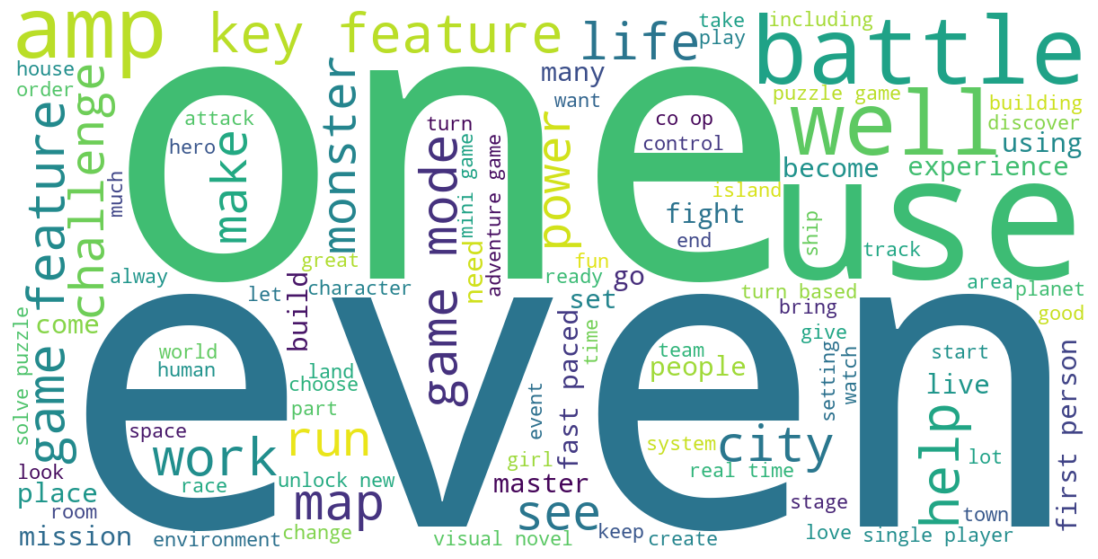

In [ ]:
# Cria a nuvem de palavras mais utilizadas
from wordcloud import WordCloud

nuvem = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(texto_limpo)

# Exibe
plt.figure(figsize=(15, 7))
plt.imshow(nuvem, interpolation="bilinear")
plt.axis("off")
plt.show()

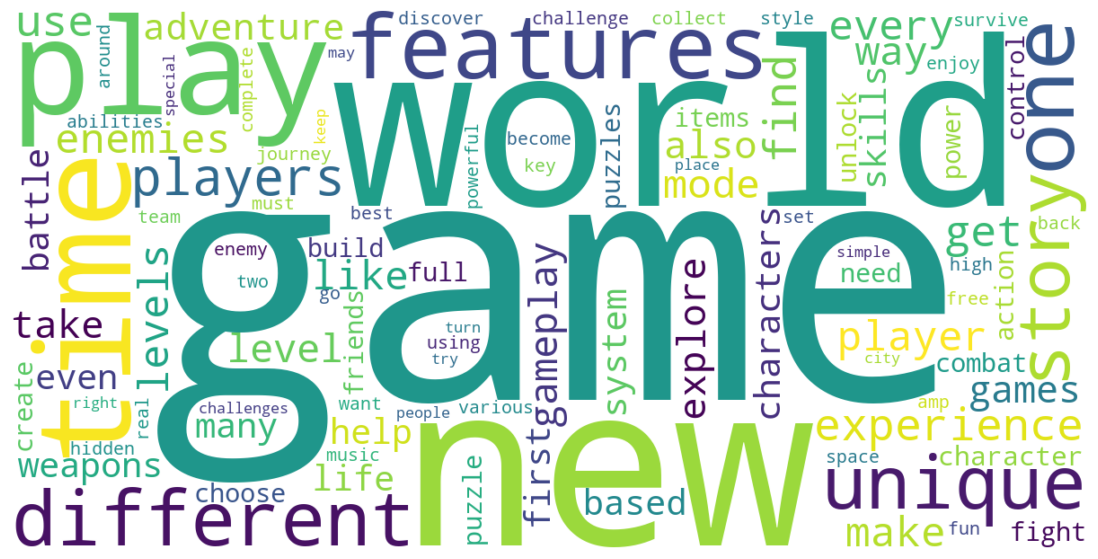

In [ ]:
# 100 palavras mais frequentes
frequentes = dict(frequencia.most_common(100))

# Gera a nuvem a partir das frequências
nuvem = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(frequentes)

# Exibe
plt.figure(figsize=(15, 7))
plt.imshow(nuvem, interpolation="bilinear")
plt.axis("off")
plt.show()

# 10. Idiomas

## `supported_languages`

Um jogo pode suportar vários idiomas. Por isso, precisamos tratar essa variável como **multivalorada**.

Primeiro vamos observar como ela está armazenada.

In [ ]:
dados["supported_languages"].dropna().head(10).tolist()

[array([], dtype=object),
 array(['English'], dtype=object),
 array(['English', 'French', 'German', 'Russian'], dtype=object),
 array(['Korean'], dtype=object),
 array(['English'], dtype=object),
 array(['English', 'French', 'Italian', 'German', 'Spanish - Spain',
        'Polish', 'Portuguese - Portugal', 'Russian', 'Turkish'],
       dtype=object),
 array(['English'], dtype=object),
 array(['English'], dtype=object),
 array(['English', 'French', 'Italian', 'German', 'Spanish - Spain',
        'Bulgarian', 'Simplified Chinese', 'Traditional Chinese', 'Korean',
        'Danish', 'Spanish - Latin America', 'Finnish', 'Greek', 'Dutch',
        'Hungarian', 'Japanese', 'Norwegian', 'Polish',
        'Portuguese - Portugal', 'Portuguese - Brazil', 'Romanian',
        'Russian', 'Swedish', 'Thai', 'Czech', 'Turkish', 'Ukrainian',
        'Vietnamese', 'Arabic'], dtype=object),
 array(['English', 'French', 'Italian', 'German', 'Spanish - Spain',
        'Arabic', 'Bulgarian', 'Traditional Ch

In [ ]:
idiomas = dados.explode("supported_languages")

idiomas_contagem = (
    idiomas["supported_languages"]
    .value_counts()
    .reset_index()
)

idiomas_contagem.columns = ["idioma", "quantidade_jogos"]

idiomas_contagem

,idioma,quantidade_jogos
0,English,110592
1,Simplified Chinese,34185
2,German,30124
3,French,29935
4,Japanese,29661
...,...,...
127,Italian[b][/b],1
128,Spanish - Spain[b][/b],1
129,Korean[b][/b],1
130,Japanese \r\n\r\n[b][/b],1


In [ ]:
# Limpeza do Idioma
import re
import numpy as np

def limpar_idiomas(valor):

    # Se for nulo
    if valor is None:
        return []

    # Converte array numpy para lista
    if isinstance(valor, np.ndarray):
        valor = valor.tolist()

    # Se for uma lista
    if isinstance(valor, list):
        idiomas = valor
    else:
        idiomas = [valor]

    idiomas_limpos = []

    for idioma in idiomas:

        # Converte para texto
        idioma = str(idioma)

        # Remove [b], [/b] e outros códigos entre colchetes
        idioma = re.sub(r"\[.*?\]", "", idioma)

        # Remove \r, \n e espaços extras
        idioma = re.sub(r"\s+", " ", idioma).strip()

        # Adiciona somente se não estiver vazio
        if idioma:
            idiomas_limpos.append(idioma)

    return idiomas_limpos

dados["supported_languages"] = dados["supported_languages"].apply(
    limpar_idiomas
)

dados["supported_languages"].explode().value_counts()

supported_languages
English                                                  110596
Simplified Chinese                                        34185
German                                                    30127
French                                                    29937
Japanese                                                  29662
                                                          ...  
Japanese (all with full audio support)                        1
Russian English Spanish - Spain French Japanese Czech         1
Traditional Chinese (text only)                               1
Hungarian,Polish                                              1
English Dutch English                                         1
Name: count, Length: 119, dtype: int64

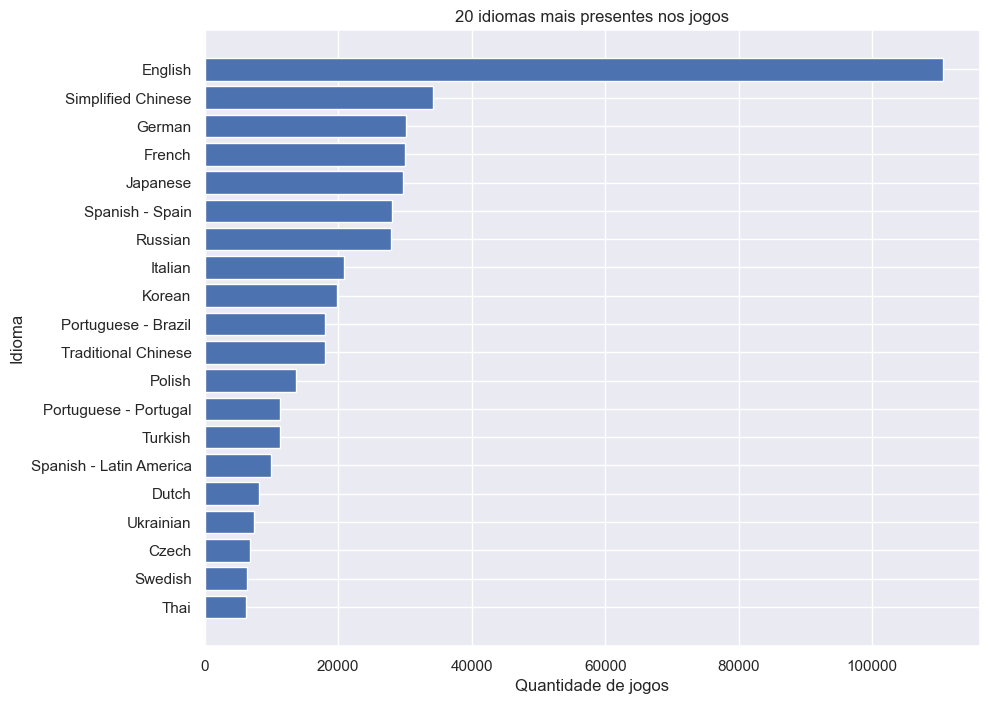

In [ ]:
top_20_idiomas = idiomas_contagem.head(20).sort_values(
    "quantidade_jogos"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_20_idiomas["idioma"],
    top_20_idiomas["quantidade_jogos"]
)

plt.title("20 idiomas mais presentes nos jogos")
plt.xlabel("Quantidade de jogos")
plt.ylabel("Idioma")

plt.show()

## `full_audio_languages`

Esse campo indica idiomas com **áudio completo**. É diferente de simplesmente suportar um idioma na interface ou nas legendas.

In [ ]:
dados["full_audio_languages"].dropna().head(10).tolist()

[array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array(['Korean'], dtype=object),
 array(['English'], dtype=object),
 array(['English', 'Turkish'], dtype=object),
 array([], dtype=object),
 array(['English'], dtype=object),
 array(['English', 'French', 'Italian', 'German', 'Spanish - Spain',
        'Bulgarian', 'Simplified Chinese', 'Traditional Chinese', 'Korean',
        'Danish', 'Spanish - Latin America', 'Finnish', 'Greek', 'Dutch',
        'Hungarian', 'Japanese', 'Norwegian', 'Polish',
        'Portuguese - Portugal', 'Portuguese - Brazil', 'Romanian',
        'Russian', 'Swedish', 'Thai', 'Czech', 'Turkish', 'Ukrainian',
        'Vietnamese', 'Arabic'], dtype=object),
 array([], dtype=object)]

In [ ]:
audio_idiomas = (
    dados
    .explode("full_audio_languages")
    ["full_audio_languages"]
    .value_counts()
    .reset_index()
)

audio_idiomas.columns = [
    "idioma",
    "quantidade_jogos"
]

audio_idiomas

,idioma,quantidade_jogos
0,English,45170
1,Simplified Chinese,8355
2,Japanese,7376
3,Russian,6764
4,German,6116
...,...,...
115,Italian[b][/b],1
116,Spanish - Spain[b][/b],1
117,Korean[b][/b],1
118,Japanese \r\n\r\n[b][/b],1


In [ ]:
# limpar e normalizar full_audio_languages
import re
import html
import numpy as np

def limpar_idiomas(valor):

    if valor is None:
        return []

    if isinstance(valor, np.ndarray):
        valor = valor.tolist()

    if not isinstance(valor, list):
        valor = [valor]

    idiomas_limpos = []

    for idioma in valor:

        texto = str(idioma)

        # Decodifica HTML - &amp 
        for _ in range(5):
            texto_novo = html.unescape(texto)
            if texto_novo == texto:
                break
            texto = texto_novo

        # Remove tags HTML, como <strong>, <br />, etc.
        texto = re.sub(r"<[^>]+>", " ", texto)

        # Remove códigos entre colchetes, como [b][/b]
        texto = re.sub(r"\[.*?\]", " ", texto)

        # Remove espaços, \r, \n e múltiplos espaços
        texto = re.sub(r"\s+", " ", texto).strip()

        if texto:
            idiomas_limpos.append(texto)

    # Remove duplicados
    return list(dict.fromkeys(idiomas_limpos))

# aplicamos somente ao campo de áudio
dados["full_audio_languages"] = (
    dados["full_audio_languages"]
    .apply(limpar_idiomas)
)

# criar o dataset para o gráfico
audio_idiomas = (
    dados["full_audio_languages"]
    .explode()
    .value_counts()
    .reset_index()
)

audio_idiomas.columns = [
    "idioma",
    "quantidade_jogos"
]

audio_idiomas

,idioma,quantidade_jogos
0,English,45177
1,Simplified Chinese,8355
2,Japanese,7380
3,Russian,6765
4,German,6121
...,...,...
98,Sorani,1126
99,Dari,1125
100,Tswana,1125
101,K'iche',1124


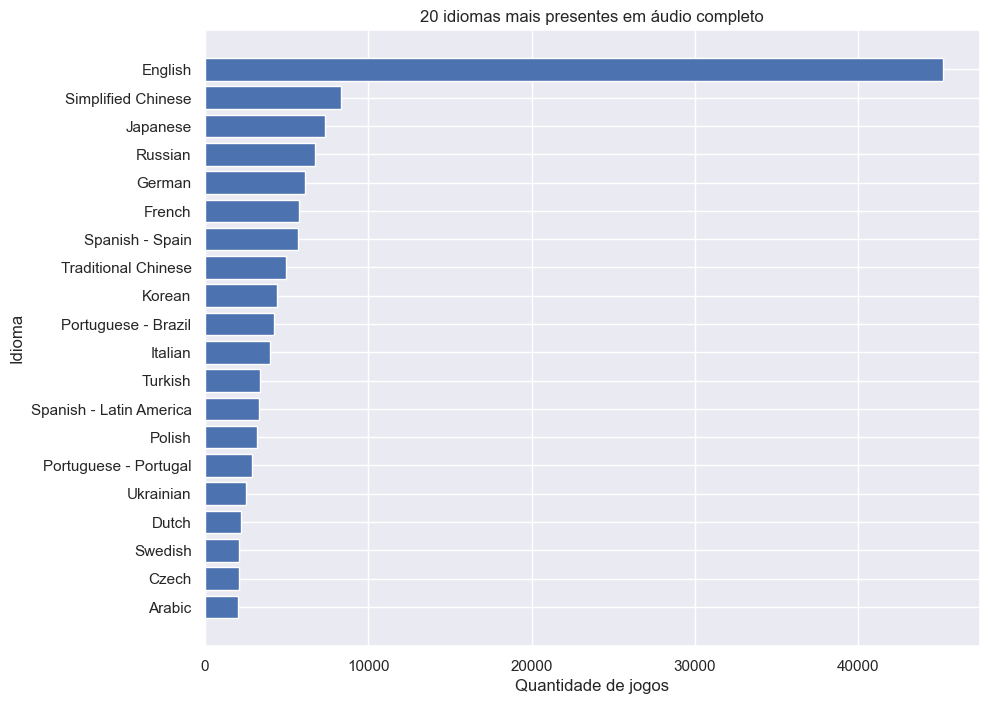

In [ ]:
# Os 20 idiomas com mais jogos com áudio
top_20_audio = (
    audio_idiomas
    .head(20)
    .sort_values("quantidade_jogos")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_20_audio["idioma"],
    top_20_audio["quantidade_jogos"]
)

plt.title("20 idiomas mais presentes em áudio completo")
plt.xlabel("Quantidade de jogos")
plt.ylabel("Idioma")

plt.show()

# 11. Avaliações dos jogadores

`positive` e `negative` e `reviews`

Vamos criar duas métricas auxiliares:

- `total_reviews`: total de avaliações;
- `positive_rate`: proporção de avaliações positivas.

In [ ]:
dados["total_reviews"] = (
    dados["positive"].fillna(0) +
    dados["negative"].fillna(0)
)

dados["positive_rate"] = np.where(
    dados["total_reviews"] > 0,
    dados["positive"] / dados["total_reviews"],
    np.nan
)

dados[[
    "name",
    "positive",
    "negative",
    "total_reviews",
    "positive_rate"
]].sort_values(
    "total_reviews",
    ascending=False
).head(20)

,name,positive,negative,total_reviews,positive_rate
45509,Counter-Strike 2,7642084,1173003,8815087,0.866932
8878,PUBG: BATTLEGROUNDS,1520457,1037487,2557944,0.594406
4193,Dota 2,2037143,461826,2498969,0.815193
59122,Grand Theft Auto V Legacy,1739980,250576,1990556,0.874118
10927,Terraria,1373979,35494,1409473,0.974818
40969,Tom Clancy's Rainbow Six® Siege X,1172854,225730,1398584,0.838601
5377,Rust,1071135,156649,1227784,0.872413
57377,Team Fortress 2,1044264,117208,1161472,0.899087
35440,Garry's Mod,1122546,37161,1159707,0.967957
44134,Black Myth: Wukong,1111720,38378,1150098,0.966631


# 12. Avaliação externa

`metacritic_score`
Nota atribuída pelo Metacritic, quando disponível. Permite comparar a recepção crítica externa com outros indicadores do jogo.

`metacritic_url`
Endereço da página correspondente no Metacritic.

`user_score`
Pontuação de usuários disponibilizada nesse campo.

`score_rank`
Classificação relacionada à avaliação dos usuários.


In [ ]:
# Dados ordenados por score_rank
dados[[
    "name",
    "genres",    
    "score_rank",
    "metacritic_score",
    "user_score"    
]].sort_values(
    "score_rank",    
    ascending=False
).head(20)

,name,genres,score_rank,metacritic_score,user_score
105901,You Must be 18 or Older to Enter,"[Action, Adventure, Free To Play, Indie, Simulation]",99,0,83
76023,BOOBS SAGA: Prepare To Hentai Edition,"[Action, Adventure, Massively Multiplayer]",99,0,77
48183,VR Paradise - Steam Edition,"[Indie, Simulation]",99,0,73
56610,Technolust,"[Adventure, Indie]",99,0,69
71761,Undress Tournament,"[Adventure, Casual, Free To Play, RPG]",99,0,57
96391,Seed of the Dead,"[Action, Casual, Indie]",99,0,84
38005,Hentai 2+2=4,"[Adventure, Casual, Indie]",99,0,61
51717,Hentai Dojo,"[Casual, Indie]",99,0,65
92135,Hentai Case Opening,"[Casual, Indie]",99,0,63
20331,HOT FIT!,[Adventure],99,0,80


In [ ]:
dados[[
    "name",
    "genres",
    "metacritic_score",
    "metacritic_url",
    "user_score",
    "score_rank"
]].sort_values(
    "metacritic_score",    
    ascending=False
).head(20)

,name,genres,metacritic_score,metacritic_url,user_score,score_rank
120346,Disco Elysium - The Final Cut,[RPG],97,https://www.metacritic.com/game/pc/disco-elysium-the-final-cut?ftag=MCD-06-10aaa1f,0,
59122,Grand Theft Auto V Legacy,"[Action, Adventure]",96,https://www.metacritic.com/game/pc/grand-theft-auto-v?ftag=MCD-06-10aaa1f,0,
59354,Baldur's Gate 3,"[Adventure, RPG, Strategy]",96,https://www.metacritic.com/game/pc/baldurs-gate-3?ftag=MCD-06-10aaa1f,0,
67387,Half-Life,[Action],96,https://www.metacritic.com/game/pc/half-life?ftag=MCD-06-10aaa1f,0,
45011,BioShock™,"[Action, RPG]",96,https://www.metacritic.com/game/pc/bioshock?ftag=MCD-06-10aaa1f,0,
47877,Half-Life 2,[Action],96,https://www.metacritic.com/game/pc/half-life-2?ftag=MCD-06-10aaa1f,0,
79233,Persona 5 Royal,[RPG],95,https://www.metacritic.com/game/pc/persona-5-royal?ftag=MCD-06-10aaa1f,0,
111649,Portal 2,"[Action, Adventure]",95,https://www.metacritic.com/game/pc/portal-2?ftag=MCD-06-10aaa1f,0,
38309,Portal 2,"[Action, Adventure]",95,https://www.metacritic.com/game/pc/portal-2?ftag=MCD-06-10aaa1f,0,
8947,Quake,[Action],94,https://www.metacritic.com/game/pc/quake?ftag=MCD-06-10aaa1f,0,


In [ ]:
dados["score_rank"] = pd.to_numeric(
    dados["score_rank"],
    errors="coerce"
)

# relação entre essas três variáveis:
dados[[
    "score_rank",
    "metacritic_score",
    "user_score"
]].corr()

,score_rank,metacritic_score,user_score
score_rank,1.000000,0.198174,0.891779
metacritic_score,0.198174,1.000000,-0.000296
user_score,0.891779,-0.000296,1.000000


| Relação                         |  Correlação | Interpretação            |
| ------------------------------- | ----------: | ------------------------ |
| `score_rank × metacritic_score` |   **0,198** | Positiva fraca           |
| `score_rank × user_score`       |   **0,892** | Positiva muito forte     |
| `metacritic_score × user_score` | **-0,0003** | Praticamente inexistente |


# 13. Conquistas e recomendações

`achievements`
Quantidade de conquistas disponíveis no jogo.

In [ ]:
dados["achievements"].describe()

count    124146.000000
mean         18.010520
std         140.633042
min           0.000000
25%           0.000000
50%           2.000000
75%          19.000000
max        9821.000000
Name: achievements, dtype: float64

In [ ]:
# Quantidade de conquistas disponíveis no jogo.
dados[["name", "achievements", "genres"]].sort_values(
    "achievements",
    ascending=False
).head(20)

,name,achievements,genres
76082,LOGistICAL,9821,"[Casual, Indie, Strategy]"
8313,Drive-By Hero,5394,"[Action, Casual, Indie]"
70740,Trivia Vault: Business Trivia,5000,"[Action, Casual, Simulation]"
118882,Trivia Vault: Soccer Trivia,5000,"[Action, Casual, Simulation]"
5764,Zaccaria Pinball,5000,"[Action, Casual, Indie, Racing, Simulation, Sports, Free To Play]"
101013,Trivia Vault: Food Trivia,5000,"[Action, Casual, Simulation, Strategy]"
20978,Trivia Vault: Celebrity Trivia,5000,"[Action, Casual, Simulation, Strategy]"
119693,Trivia Vault: Mini Mixed Trivia,5000,"[Action, Casual, Indie, Simulation, Strategy]"
120185,Trivia Vault: Mini Mixed Trivia 4,5000,"[Action, Casual, Indie, Simulation, Strategy]"
29400,Professor Watts Word Search: Into The Ocean,5000,"[Casual, Indie, Strategy]"


`recommendations`
Quantidade de recomendações associadas ao jogo.

In [ ]:
dados[["name", "recommendations","genres"]].sort_values(
    "recommendations",
    ascending=False
).head(20)

,name,recommendations,genres
45509,Counter-Strike 2,4830455,"[Action, Free To Play]"
59122,Grand Theft Auto V Legacy,1854262,"[Action, Adventure]"
8878,PUBG: BATTLEGROUNDS,1753261,"[Action, Adventure, Massively Multiplayer, Free To Play]"
78473,Tom Clancy's Rainbow Six® Siege X,1224102,"[Action, Free To Play]"
40969,Tom Clancy's Rainbow Six® Siege X,1223854,"[Action, Free To Play]"
38815,Tom Clancy's Rainbow Six® Siege X,1223842,"[Action, Free To Play]"
9187,Tom Clancy's Rainbow Six® Siege X,1223680,"[Action, Free To Play]"
10471,Tom Clancy's Rainbow Six® Siege X,1223678,"[Action, Free To Play]"
10927,Terraria,1163012,"[Action, Adventure, Indie, RPG]"
5377,Rust,1081623,"[Action, Adventure, Indie, Massively Multiplayer, RPG]"


# 14. Sistemas operacionais

Os campos `windows`, `mac` e `linux` são booleanos.

Vamos verificar a cobertura de cada plataforma.

In [ ]:
plataformas = ["windows", "mac", "linux"]

for coluna in plataformas:
    print(f"\n{coluna}")
    print(dados[coluna].value_counts(dropna=False))


windows
windows
True     124102
False        44
Name: count, dtype: int64

mac
mac
False    102660
True      21486
Name: count, dtype: int64

linux
linux
False    108258
True      15888
Name: count, dtype: int64


In [ ]:
cobertura = pd.DataFrame({
    "Windows": [dados["windows"].fillna(False).sum()],
    "Mac": [dados["mac"].fillna(False).sum()],
    "Linux": [dados["linux"].fillna(False).sum()]
}).T

cobertura.columns = ["jogos"]
cobertura

,jogos
Windows,124102
Mac,21486
Linux,15888


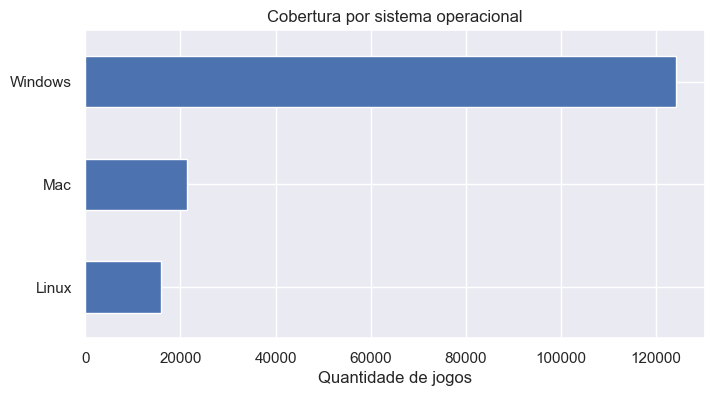

In [ ]:
cobertura["jogos"].sort_values().plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Cobertura por sistema operacional")
plt.xlabel("Quantidade de jogos")
plt.show()

### Combinações de plataformas

Os grupos não são exclusivos. Um jogo pode suportar Windows, Mac e Linux simultaneamente.

In [ ]:
# 1 → disponível em uma plataforma
# 2 → disponível em duas
# 3 → disponível em Windows, Mac e Linux

dados["platforms_count"] = (
    dados[plataformas]
    .fillna(False)
    .astype(int)
    .sum(axis=1)
)

dados["platforms_count"].value_counts().sort_index()

platforms_count
1    98229
2    14504
3    11413
Name: count, dtype: int64

In [ ]:
# relação entre quantidade de plataformas e média de proprietários
dados["alcance_comercial"] = pd.cut(
    dados["estimated_owners_mid"],
    bins=[-1, 10000, 50000, 100000, 500000, float("inf")],
    labels=[ 
        # faixas de alcance comercial:
        "Até 10 mil",
        "10 mil–50 mil",
        "50 mil–100 mil",
        "100 mil–500 mil",
        "Mais de 500 mil"
    ]
)

pd.crosstab(
    dados["platforms_count"],
    dados["alcance_comercial"]
)

alcance_comercial,Até 10 mil,10 mil–50 mil,50 mil–100 mil,100 mil–500 mil,Mais de 500 mil
platforms_count,,,,,
1,80171,8485,3859,4112,1602
2,10732,1571,771,1016,414
3,7675,1341,725,1180,492


# 15. Tempo de jogo e engajamento

`average_playtime_forever`
Tempo médio de jogo acumulado, em minutos.

Vamos converter para horas.

In [ ]:
dados["avg_playtime_forever_hours"] = (
    dados["average_playtime_forever"] / 60
)

dados[[
    "name",
    "average_playtime_forever",
    "avg_playtime_forever_hours"
]].head(10)

,name,average_playtime_forever,avg_playtime_forever_hours
0,Black Dragon Mage Playtest,0,0.000000
1,Supipara - Chapter 1 Spring Has Come!,8,0.133333
2,Mystery Solitaire The Black Raven,0,0.000000
3,버튜버 파라노이아 - Vtuber Paranoia,0,0.000000
4,Maze Quest VR,0,0.000000
5,Agony VR,0,0.000000
6,Armored Brigade II,675,11.250000
7,Galacatraz: Eject Equip Escape,0,0.000000
8,Hepta Beats,0,0.000000
9,MUMBA IV: Egypt Jewels,0,0.000000


In [ ]:
# Horas acumuladas 
dados[["name","avg_playtime_forever_hours"]].sort_values(
    "avg_playtime_forever_hours",
    ascending=False
).head(20)

,name,avg_playtime_forever_hours
27968,Avem33,57159.066667
59930,iTownGamePlay UNIVERSE,28571.250000
67121,Letters From a Rainy Day -Oceans and Lace-,5994.416667
63635,爱人 Lover,5383.050000
11278,KAMI,3278.933333
73366,秘密舞会,3157.266667
30076,VEGAS Pro 18 Edit Steam Edition,3084.300000
46758,Wizard And Minion Idle,2845.833333
76069,Love Stories: When Pastel Meets Grotesque,2646.066667
59371,Franchise Hockey Manager 9,2529.450000


## `average_playtime_2weeks`

Tempo médio de jogo nas últimas duas semanas.

In [ ]:
dados["avg_playtime_2weeks_hours"] = (
    dados["average_playtime_2weeks"] / 60
)

dados[[
    "name",
    "average_playtime_2weeks",
    "avg_playtime_2weeks_hours"
]].sort_values(
    "average_playtime_2weeks",
    ascending=False
).head(20)

,name,average_playtime_2weeks,avg_playtime_2weeks_hours
13561,Knights and Merchants,20088,334.800000
11278,KAMI,20088,334.800000
59930,iTownGamePlay UNIVERSE,20083,334.716667
16220,The Red Stare,20083,334.716667
27968,Avem33,20083,334.716667
8149,Forbidden Planet,20065,334.416667
100317,GINKA,20014,333.566667
114568,NEKOPARA Vol. 1,20014,333.566667
36605,Notes of Soul,19640,327.333333
59467,Awesomenauts,16622,277.033333


## `median_playtime_forever` e `median_playtime_2weeks`

A mediana é importante porque o tempo de jogo pode apresentar valores extremamente altos.

In [ ]:
dados[[
    "average_playtime_forever",
    "average_playtime_2weeks",
    "median_playtime_forever",
    "median_playtime_2weeks"
]].describe()

,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks
count,1.241460e+05,124146.000000,1.241460e+05,124146.000000
mean,2.054626e+02,13.628204,1.714364e+02,14.550578
std,1.114814e+04,268.710314,1.113308e+04,292.692992
min,0.000000e+00,0.000000,0.000000e+00,0.000000
25%,0.000000e+00,0.000000,0.000000e+00,0.000000
50%,0.000000e+00,0.000000,0.000000e+00,0.000000
75%,0.000000e+00,0.000000,0.000000e+00,0.000000
max,3.429544e+06,20088.000000,3.429544e+06,20088.000000


## Índice de atividade recente relativa

Podemos construir um indicador exploratório:

`average_playtime_2weeks / average_playtime_forever`

**Importante:** isso não é uma taxa de retenção. É apenas um indicador relativo de atividade recente.

In [ ]:
dados["recent_activity_index"] = np.where(
    dados["average_playtime_forever"] > 0,
    dados["average_playtime_2weeks"] /
    dados["average_playtime_forever"],
    np.nan
)

dados[[
    "name",
    "average_playtime_forever",
    "average_playtime_2weeks",
    "recent_activity_index"
]].sort_values(
    "recent_activity_index",
    ascending=False
).head(20)

,name,average_playtime_forever,average_playtime_2weeks,recent_activity_index
69001,LARA CROFT AND THE TEMPLE OF OSIRIS™,415,6049,14.575904
114568,NEKOPARA Vol. 1,1577,20014,12.691186
49767,Bulb Boy,198,1582,7.989899
30858,Atomfall,560,3605,6.437500
9685,Click and Conquer,302,1805,5.976821
89898,Deus Ex: Invisible War,102,608,5.960784
5019,LEGO® Batman™ 2: DC Super Heroes,686,4018,5.857143
104019,Worm.is: The Game,1059,6058,5.720491
76560,Wolfenstein: Youngblood,760,4288,5.642105
16772,Drakensang Online,401,2188,5.456359


# 16. Desenvolvedores e publishers

## `developers` e `publishers`

Esses campos podem conter mais de uma empresa.

Vamos contar quantos jogos estão associados a cada desenvolvedor/publisher.

In [ ]:
# padronizar campos que podem estar armazenados de diferentes formas, transformando o conteúdo em uma lista Python.

import ast
import numpy as np
import pandas as pd

def transformar_lista(valor):
    if valor is None:
        return []

    # Trata arrays do NumPy
    if isinstance(valor, np.ndarray):
        return valor.tolist()

    # Já é uma lista
    if isinstance(valor, list):
        return valor

    # Trata valores ausentes
    if pd.isna(valor):
        return []

    texto = str(valor).strip()

    if not texto:
        return []

    # Tenta interpretar como lista
    try:
        resultado = ast.literal_eval(texto)

        if isinstance(resultado, (list, tuple)):
            return list(resultado)

    except (ValueError, SyntaxError):
        pass

    # Caso seja uma string separada por vírgulas
    if "," in texto:
        return [
            item.strip()
            for item in texto.split(",")
            if item.strip()
        ]

    return [texto]

In [ ]:
dados["developers_list"] = dados["developers"].apply(transformar_lista)
dados["publishers_list"] = dados["publishers"].apply(transformar_lista)

devs = dados.explode("developers_list")
pubs = dados.explode("publishers_list")

print("Principais desenvolvedores:")
display(devs["developers_list"].value_counts().head(20))

print("\nPrincipais publishers:")
display(pubs["publishers_list"].value_counts().head(20))

Principais desenvolvedores:


developers_list
EroticGamesClub               232
Choice of Games               179
Boogygames Studios            157
Laush Dmitriy Sergeevich      152
Bully Revenge Studios         146
Creobit                       145
Gamesforgames                 133
Tero Lunkka                   124
Cyber Keks                    121
Hosted Games                  119
KOEI TECMO GAMES CO., LTD.    119
Sokpop Collective             112
Do Games Limited              101
Hede                          100
Archor Wright                  99
King Kong                      97
Square Enix                    96
Valkeala Software              96
Blender Games                  94
Dnovel                         93
Name: count, dtype: int64


Principais publishers:


publishers_list
BFG Entertainment                  554
8floor                             268
EroticGamesClub                    232
PlayWay S.A.                       220
Strategy First                     206
Conglomerate 5                     197
Kagura Games                       197
Hede                               186
HH-Games                           184
Choice of Games                    179
Laush Studio                       172
Sekai Project                      168
THQ Nordic                         166
Plug In Digital                    161
Boogygames Studios                 157
Ubisoft                            153
Electronic Arts                    153
Square Enix                        152
DigiPen Institute of Technology    146
Bully Revenge Studios              146
Name: count, dtype: int64

### Desenvolvedores por alcance estimado

Como exercício, podemos comparar a mediana de proprietários estimados por desenvolvedor, exigindo pelo menos 3 jogos.

In [ ]:
dev_analise = (
    devs.dropna(subset=["developers_list", "estimated_owners_mid"])
    .groupby("developers_list")
    .agg(
        jogos=("name", "count"),
        mediana_proprietarios=("estimated_owners_mid", "median")
    )
)

dev_analise[
    dev_analise["jogos"] >= 3
].sort_values(
    "mediana_proprietarios",
    ascending=False
).head(20)

,jogos,mediana_proprietarios
developers_list,,
Wargaming Group Limited,4,8250000.0
Daybreak Game Company,3,7500000.0
Valve,36,7500000.0
Ubisoft Quebec,3,7500000.0
Rockstar North,4,7500000.0
TaleWorlds Entertainment,4,4500000.0
Expansive Worlds,4,3925000.0
Supergiant Games,5,3500000.0
Hazelight Studios,4,3500000.0


# 17. Gêneros

## `genres`

Gêneros são multivalorados. Um jogo pode pertencer a vários gêneros.

In [ ]:
dados["genres_list"] = dados["genres"].apply(transformar_lista)

generos = dados.explode("genres_list")

generos[["name", "genres_list"]].head(20)

,name,genres_list
0,Black Dragon Mage Playtest,NaN
1,Supipara - Chapter 1 Spring Has Come!,Adventure
2,Mystery Solitaire The Black Raven,Casual
3,버튜버 파라노이아 - Vtuber Paranoia,Casual
3,버튜버 파라노이아 - Vtuber Paranoia,Indie
3,버튜버 파라노이아 - Vtuber Paranoia,Simulation
4,Maze Quest VR,Action
4,Maze Quest VR,Early Access
5,Agony VR,Action
5,Agony VR,Adventure


In [ ]:
contagem_generos = generos["genres_list"].value_counts()

contagem_generos.head(20)

genres_list
Indie                    81746
Casual                   50886
Action                   46743
Adventure                45726
Simulation               24504
Strategy                 22725
RPG                      21259
Free To Play             12366
Early Access             11324
Sports                    4925
Racing                    4117
Massively Multiplayer     2563
Utilities                 1083
Design & Illustration      583
Animation & Modeling       481
Education                  461
Violent                    414
Video Production           339
Game Development           322
Gore                       257
Name: count, dtype: int64

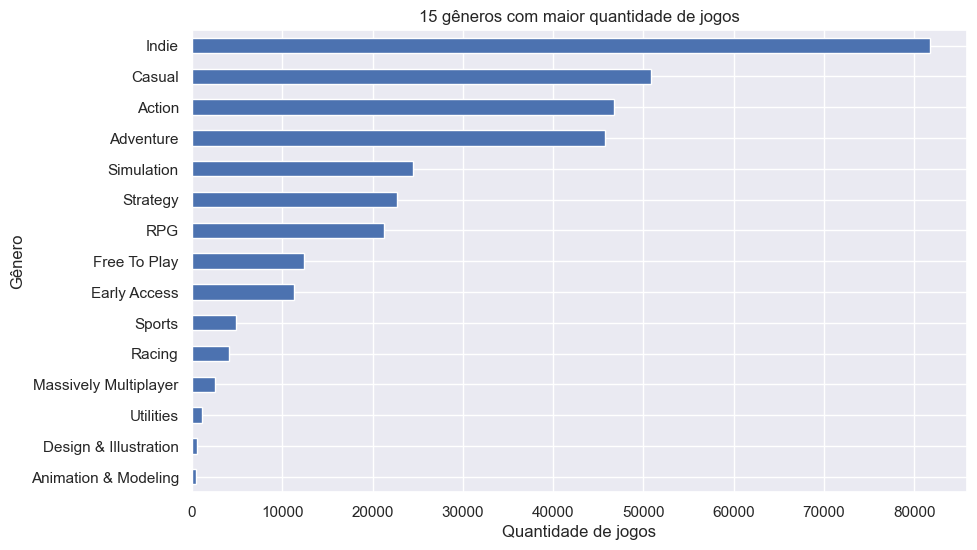

In [ ]:
contagem_generos.head(15).sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("15 gêneros com maior quantidade de jogos")
plt.xlabel("Quantidade de jogos")
plt.ylabel("Gênero")
plt.show()

### Gênero × proprietários estimados

A quantidade de jogos de um gênero e seu alcance comercial são perguntas diferentes.

In [ ]:
genero_analise = (
    generos.dropna(subset=["genres_list", "estimated_owners_mid"])
    .groupby("genres_list")
    .agg(
        jogos=("name", "count"),
        mediana_proprietarios=("estimated_owners_mid", "median"),
        media_proprietarios=("estimated_owners_mid", "mean")
    )
    .sort_values("mediana_proprietarios", ascending=False)
)

genero_analise.head(20)

,jogos,mediana_proprietarios,media_proprietarios
genres_list,,,
Movie,2,380000.0,380000.000000
360 Video,1,10000.0,10000.000000
Accounting,30,10000.0,24666.666667
Adventure,45726,10000.0,97320.998994
Action,46743,10000.0,142821.171084
Audio Production,227,10000.0,43061.674009
Casual,50886,10000.0,39370.062493
Design & Illustration,583,10000.0,110994.854202
Animation & Modeling,481,10000.0,131091.476091


# 18. Categorias

## `categories`

Categorias descrevem características funcionais, como multiplayer, single-player e recursos da Steam.

In [ ]:
dados["categories_list"] = dados["categories"].apply(transformar_lista)

categorias = dados.explode("categories_list")

categorias["categories_list"].value_counts().head(20)

categories_list
Single-player                   109454
Family Sharing                   97237
Steam Achievements               56512
Steam Cloud                      30807
Full controller support          25765
Multi-player                     20524
Partial Controller Support       13789
PvP                              12731
Steam Trading Cards              11385
Co-op                            11157
Steam Leaderboards                9324
Online PvP                        9025
Remote Play Together              7817
Shared/Split Screen               7496
Custom Volume Controls            7085
Playable without Timed Input      7004
Online Co-op                      6887
VR Only                           5807
Tracked Controller Support        5635
Stats                             5156
Name: count, dtype: int64

In [ ]:
categorias_analise = (
    categorias.dropna(subset=["categories_list", "estimated_owners_mid"])
    .groupby("categories_list")
    .agg(
        jogos=("name", "count"),
        mediana_proprietarios=("estimated_owners_mid", "median")
    )
    .sort_values("mediana_proprietarios", ascending=False)
)

categorias_analise.head(20)

,jogos,mediana_proprietarios
categories_list,,
Valve Anti-Cheat enabled,115,1500000.0
Mods,2,1125000.0
Mods (require HL2),2,450000.0
Remote Play on Tablet,1106,150000.0
SteamVR Collectibles,38,150000.0
Remote Play on Phone,954,75000.0
Includes Source SDK,59,35000.0
Remote Play on TV,2598,35000.0
Steam Turn Notifications,98,35000.0


# 19. Tags

## `tags`

Tags permitem uma análise mais semântica dos jogos.

In [ ]:
dados["tags_list"] = dados["tags"].apply(transformar_lista)

tags = dados.explode("tags_list")

tags["tags_list"].value_counts().head(30)

Series([], Name: count, dtype: int64)

### Tags dos jogos com maior alcance estimado

In [ ]:
top_jogos = dados.nlargest(100, "estimated_owners_mid")

tags_top = top_jogos.explode("tags_list")

tags_top["tags_list"].value_counts().head(30)

Series([], Name: count, dtype: int64)

# 20. Imagens e vídeos

## `header_image`, `screenshots` e `movies`

Esses campos são principalmente úteis para análises multimídia.

Nesta etapa, vamos apenas verificar a disponibilidade dos dados.

In [ ]:
colunas_midia = [
    "header_image",
    "screenshots",
    "movies"
]

for coluna in colunas_midia:
    print(f"{coluna}: {dados[coluna].notna().sum():,} preenchidos de {len(dados):,}")

header_image: 124,146 preenchidos de 124,146
screenshots: 124,146 preenchidos de 124,146
movies: 124,146 preenchidos de 124,146


In [ ]:
dados[colunas_midia]

,header_image,screenshots,movies
0,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/header.jpg?t=1699268702,[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/ss_7d9504b958d0b143d053d31cb74b375daba33...,[]
1,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/496350/header.jpg?t=1725519097,[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/496350/ss_0a5ff85870a1c2221e495b75a5c7b9e248eb32...,[]
2,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/1034400/header.jpg?t=1687434115,[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/1034400/ss_12d8bb27a16046fe548818dcd0f5d7d0e2038...,[]
3,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3292190/header.jpg?t=1742217574,[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3292190/ss_87f071dbf846e7832ff49d68b0d7a8b6509bc...,[]
4,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3631080/2a78ae30e350862e415889f097e422855eca25b9/...,[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3631080/3c3874df57f1a1a1f544e81ee21581f8b52140b5...,[]
...,...,...,...
124141,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/4123530/3b20aaa1d333c5fc57c0b45635cfd0bc56556aa7/...,[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/4123530/59b99b9c4f617035fff8be0d1a7307a2695ec5c1...,[]
124142,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/4272850/05089da656864d735f9fc98d5c9e0f91dc6d6019/...,[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/4272850/3497d92c3062c8c9aa2997eadf9c8f0c26fb6234...,[]
124143,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/4302310/1845535e88b37628d84b75cdacc7353651e36295/...,[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/4302310/03a3cc392d0aea697c78f3ff12513eb117839210...,[]
124144,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/4301980/953127236ca67621b53da03424c522cfa2919e62/...,[https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/4301980/1aa911d8d8698ab8e87c731419ae5671ea29ea00...,[]


# 21. Website e suporte

## `website`, `support_url` e `support_email`

São campos informativos que também permitem investigar a disponibilidade de canais externos.

In [ ]:
colunas_web = [
    "website",
    "support_url",
    "support_email"
]

for coluna in colunas_web:
    print(f"{coluna}: {dados[coluna].notna().sum():,} preenchidos")

website: 124,146 preenchidos
support_url: 124,146 preenchidos
support_email: 124,146 preenchidos


In [ ]:
dados[colunas_web]

,website,support_url,support_email
0,,,
1,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com
2,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net
3,,,yujingamesc@gmail.com
4,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com
...,...,...,...
124141,,,kmbox.biz@gmail.com
124142,,,
124143,,,kimhyoungjo@hotmail.com
124144,,,1808467533@qq.com


# 22. Packages

## `packages`

É um campo mais complexo, potencialmente contendo informações estruturadas sobre pacotes.

Nesta primeira exploração, vamos apenas observar alguns exemplos e o tipo dos valores.

In [ ]:
print(dados["packages"].dtype)
dados[["name", "packages"]].dropna().head(5)

object


,name,packages
0,Black Dragon Mage Playtest,[]
1,Supipara - Chapter 1 Spring Has Come!,"[{""title"": ""Buy Supipara - Chapter 1 Spring Has Come!"", ""description"": """", ""subs"": [{""text"": ""Supipara - Alice the m..."
2,Mystery Solitaire The Black Raven,"[{""title"": ""Buy Mystery Solitaire The Black Raven"", ""description"": """", ""subs"": [{""text"": ""Mystery Solitaire The Blac..."
3,버튜버 파라노이아 - Vtuber Paranoia,"[{""title"": ""Buy \ubc84\ud29c\ubc84 \ud30c\ub77c\ub178\uc774\uc544 - Vtuber Paranoia"", ""description"": """", ""subs"": [{""..."
4,Maze Quest VR,"[{""title"": ""Buy Maze Quest VR"", ""description"": """", ""subs"": [{""text"": ""Maze Quest VR - $4.99"", ""description"": """", ""pr..."


# 23. Correlações entre variáveis numéricas

Agora que conhecemos os principais campos, podemos observar algumas associações entre variáveis numéricas.

**Correlação não significa causalidade.**

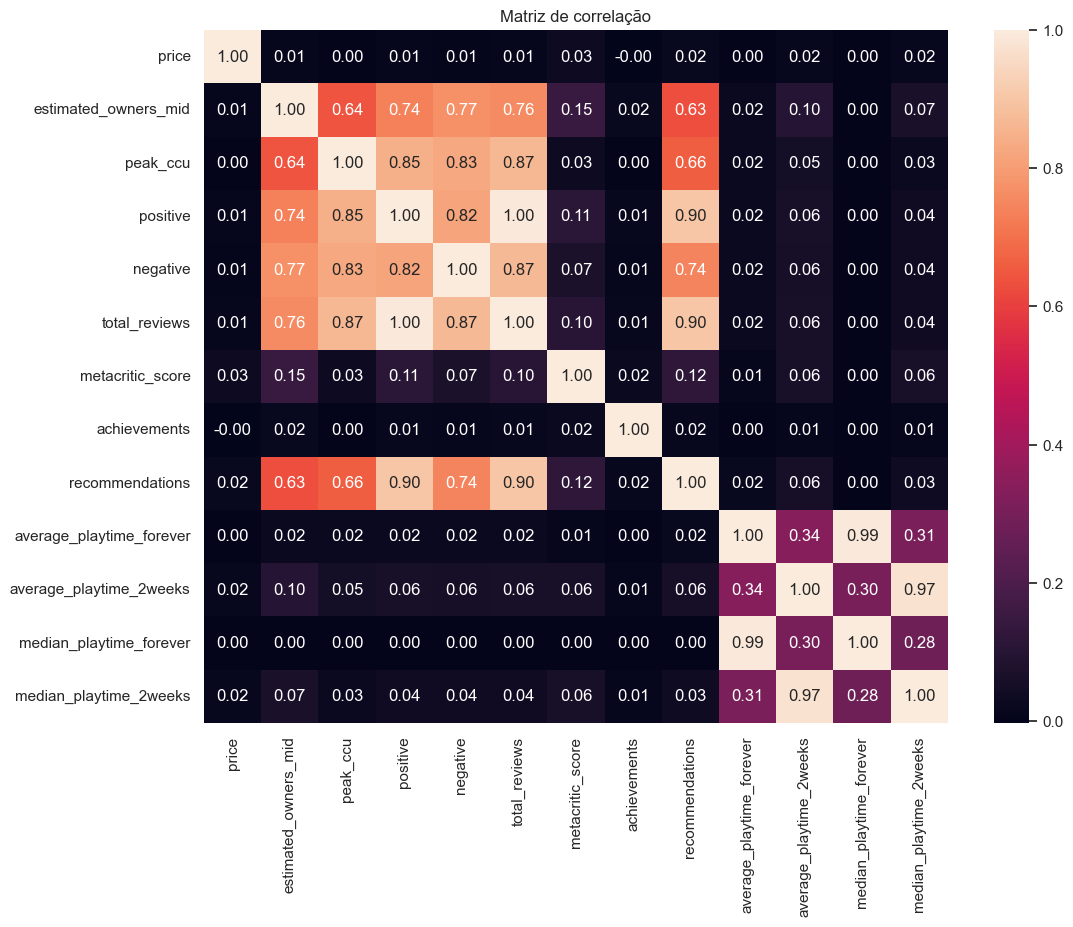

In [ ]:
colunas_numericas = [
    "price",
    "estimated_owners_mid",
    "peak_ccu",
    "positive",
    "negative",
    "total_reviews",
    "metacritic_score",
    "achievements",
    "recommendations",
    "average_playtime_forever",
    "average_playtime_2weeks",
    "median_playtime_forever",
    "median_playtime_2weeks"
]

corr = dados[colunas_numericas].corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Matriz de correlação")
plt.show()

In [ ]:
# Exportação de dados.
dados.to_csv("games_steam_ead.csv", index=False)